# Обучение детектора чека на YOLOv8

В этом ноутбуке мы дообучаем детектор, который находит чек на фотографии. Это первый из обучаемых нейросетевых компонентов системы. Его задача - локализовать чек на произвольном фоне, чтобы дальше можно было выправить перспективу и подать ровный, обрезанный чек в модель распознавания.

За основу берём YOLOv8. Учить с нуля смысла нет, поэтому мы дообучаем её под один новый класс - чек. Данные для обучения это около семисот фотографий чеков с размеченными рамками, расширенные нашими аугментациями под реальные условия съёмки: наклоны, блики, шум, разную яркость.

Обучение идёт в Colab на GPU, потому что на процессоре это заметно медленнее. Веса и результаты сохраняем на Google Drive, чтобы они не пропали при отключении сессии.

Что хотим получить в итоге: обученный детектор с измеренным качеством.

In [1]:
import torch

print("GPU доступен:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Устройство:", torch.cuda.get_device_name(0))

GPU доступен: True
Устройство: Tesla T4


In [2]:
!pip install ultralytics albumentations -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 76.0 MB/s eta 0:00:00


## Подключение Google Drive

Монтируем Drive, где лежит залитый датасет и куда будем сохранять обученные веса.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
from pathlib import Path

data_root = Path("/content/drive/MyDrive/receipt-ai/detector/data/processed/detector")
print("Папка датасета существует:", data_root.exists())

for split in ["train", "valid", "test"]:
    img_dir = data_root / split / "images"
    if img_dir.exists():
        n = len(list(img_dir.glob("*.jpg")))
        print(f"{split}: {n} картинок")
    else:
        print(f"{split}: папки нет")

Папка датасета существует: True
train: 690 картинок
valid: 39 картинок
test: 21 картинок


## Конфигурация датасета для YOLO

YOLO читает пути к данным из файла data.yaml. Создаём конфиг заново, уже с путями Colab.

In [9]:
yaml_path = data_root / "data_colab.yaml"
yaml_text = (
    f"train: {(data_root / 'train' / 'images').as_posix()}\n"
    f"val: {(data_root / 'valid' / 'images').as_posix()}\n"
    f"test: {(data_root / 'test' / 'images').as_posix()}\n"
    f"nc: 1\n"
    f"names: ['Receipt']\n"
)
yaml_path.write_text(yaml_text)
print(yaml_text)
print("Конфиг записан:", yaml_path)

train: /content/drive/MyDrive/receipt-ai/detector/data/processed/detector/train/images
val: /content/drive/MyDrive/receipt-ai/detector/data/processed/detector/valid/images
test: /content/drive/MyDrive/receipt-ai/detector/data/processed/detector/test/images
nc: 1
names: ['Receipt']

Конфиг записан: /content/drive/MyDrive/receipt-ai/detector/data/processed/detector/data_colab.yaml


## Аугментации данных

Перед обучением посмотрим, как выглядят аугментации, которыми мы расширили обучающую выборку. Из каждой исходной фотографии генерируется несколько искажённых вариантов: с наклоном, изменённой яркостью, перспективными искажениями, шумом и бликами. Это учит детектор узнавать чек в разных условиях съёмки, а не только на идеальных кадрах. Рамка объекта при этом пересчитывается синхронно с изображением.

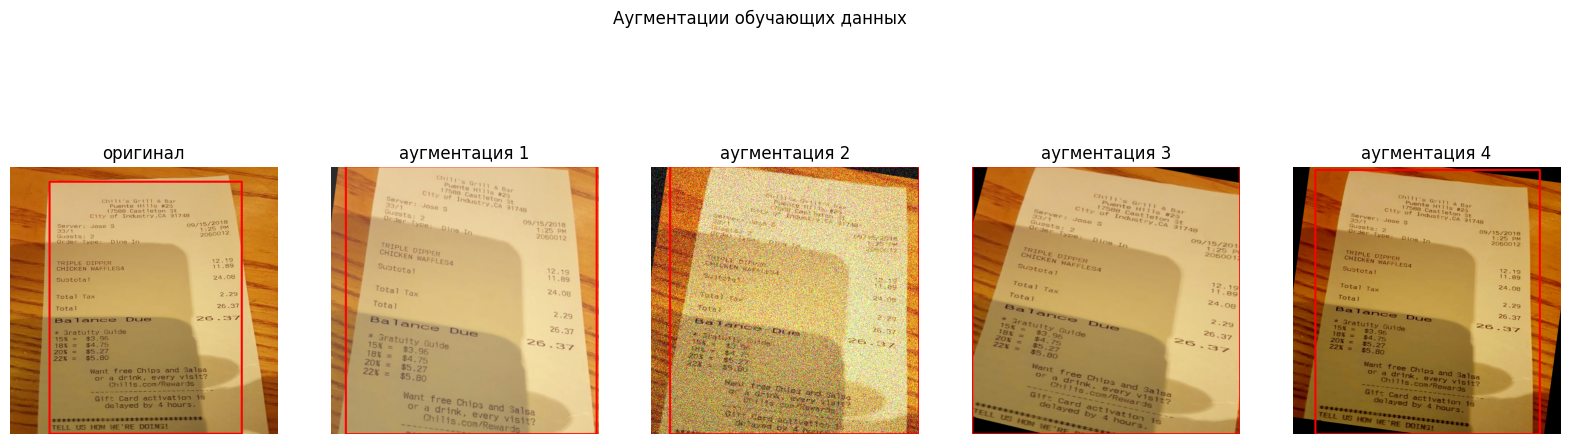

In [10]:
import cv2
import random
import albumentations as A
import matplotlib.pyplot as plt

pipeline = A.Compose(
    [
        A.Rotate(limit=12, border_mode=0, p=0.7),
        A.Perspective(scale=(0.02, 0.08), p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.6),
        A.OneOf([A.GaussNoise(p=1.0), A.ISONoise(p=1.0)], p=0.4),
        A.OneOf([A.MotionBlur(blur_limit=5, p=1.0), A.GaussianBlur(blur_limit=5, p=1.0)], p=0.3),
        A.RandomSunFlare(flare_roi=(0, 0, 1, 1), src_radius=120, p=0.2),
    ],
    bbox_params=A.BboxParams(format="yolo", min_visibility=0.3, label_fields=["class_labels"]),
)

img_dir = data_root / "train" / "images"
lbl_dir = data_root / "train" / "labels"
originals = [p for p in img_dir.glob("*.jpg") if "_aug" not in p.name]
sample_path = random.choice(originals)

image = cv2.cvtColor(cv2.imread(str(sample_path)), cv2.COLOR_BGR2RGB)
lines = (lbl_dir / (sample_path.stem + ".txt")).read_text().strip().splitlines()
bboxes = [list(map(float, l.split()))[1:] for l in lines]
classes = [int(l.split()[0]) for l in lines]

def draw(img, boxes):
    out = img.copy()
    h, w = out.shape[:2]
    for cx, cy, bw, bh in boxes:
        x1, y1 = int((cx - bw/2)*w), int((cy - bh/2)*h)
        x2, y2 = int((cx + bw/2)*w), int((cy + bh/2)*h)
        cv2.rectangle(out, (x1, y1), (x2, y2), (255, 0, 0), 3)
    return out

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
axes[0].imshow(draw(image, bboxes)); axes[0].set_title("оригинал"); axes[0].axis("off")
for i in range(1, 5):
    r = pipeline(image=image, bboxes=bboxes, class_labels=classes)
    axes[i].imshow(draw(r["image"], r["bboxes"])); axes[i].set_title(f"аугментация {i}"); axes[i].axis("off")
plt.suptitle("Аугментации обучающих данных")
plt.show()

## Обучение детектора

Запускаем дообучение YOLOv8. За основу берём YOLOv8n - самую лёгкую версию, обученную на COCO. Её достаточно для одного простого класса, и она быстро обучается и работает даже на процессоре при инференсе, что важно для демо.

Веса и графики обучения сохраняются на Google Drive. Обучение идёт с ранней остановкой: если качество на валидации перестаёт расти в течение пятнадцати эпох, обучение прекращается, чтобы не тратить время и не переобучаться.

In [11]:
from ultralytics import YOLO

project_dir = "/content/drive/MyDrive/receipt-ai/runs/detector"

model = YOLO("yolov8n.pt")
results = model.train(
    data=str(yaml_path),
    epochs=60,
    imgsz=640,
    batch=16,
    project=project_dir,
    name="receipt_yolo",
    patience=15,
    plots=True,
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/receipt-ai/detector/data/processed/detector/data_colab.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=N

## Результаты обучения

Обучение остановилось на 52 эпохе ранней остановкой, лучшая модель зафиксирована на 37 эпохе. На валидации детектор показал точность 0.972, полноту 1.0, mAP50 0.995 и mAP50-95 0.839.

YOLO во время обучения сама сохранила графики: кривые функций потерь и метрик по эпохам, матрицу ошибок, примеры предсказаний. Посмотрим их.

results.png


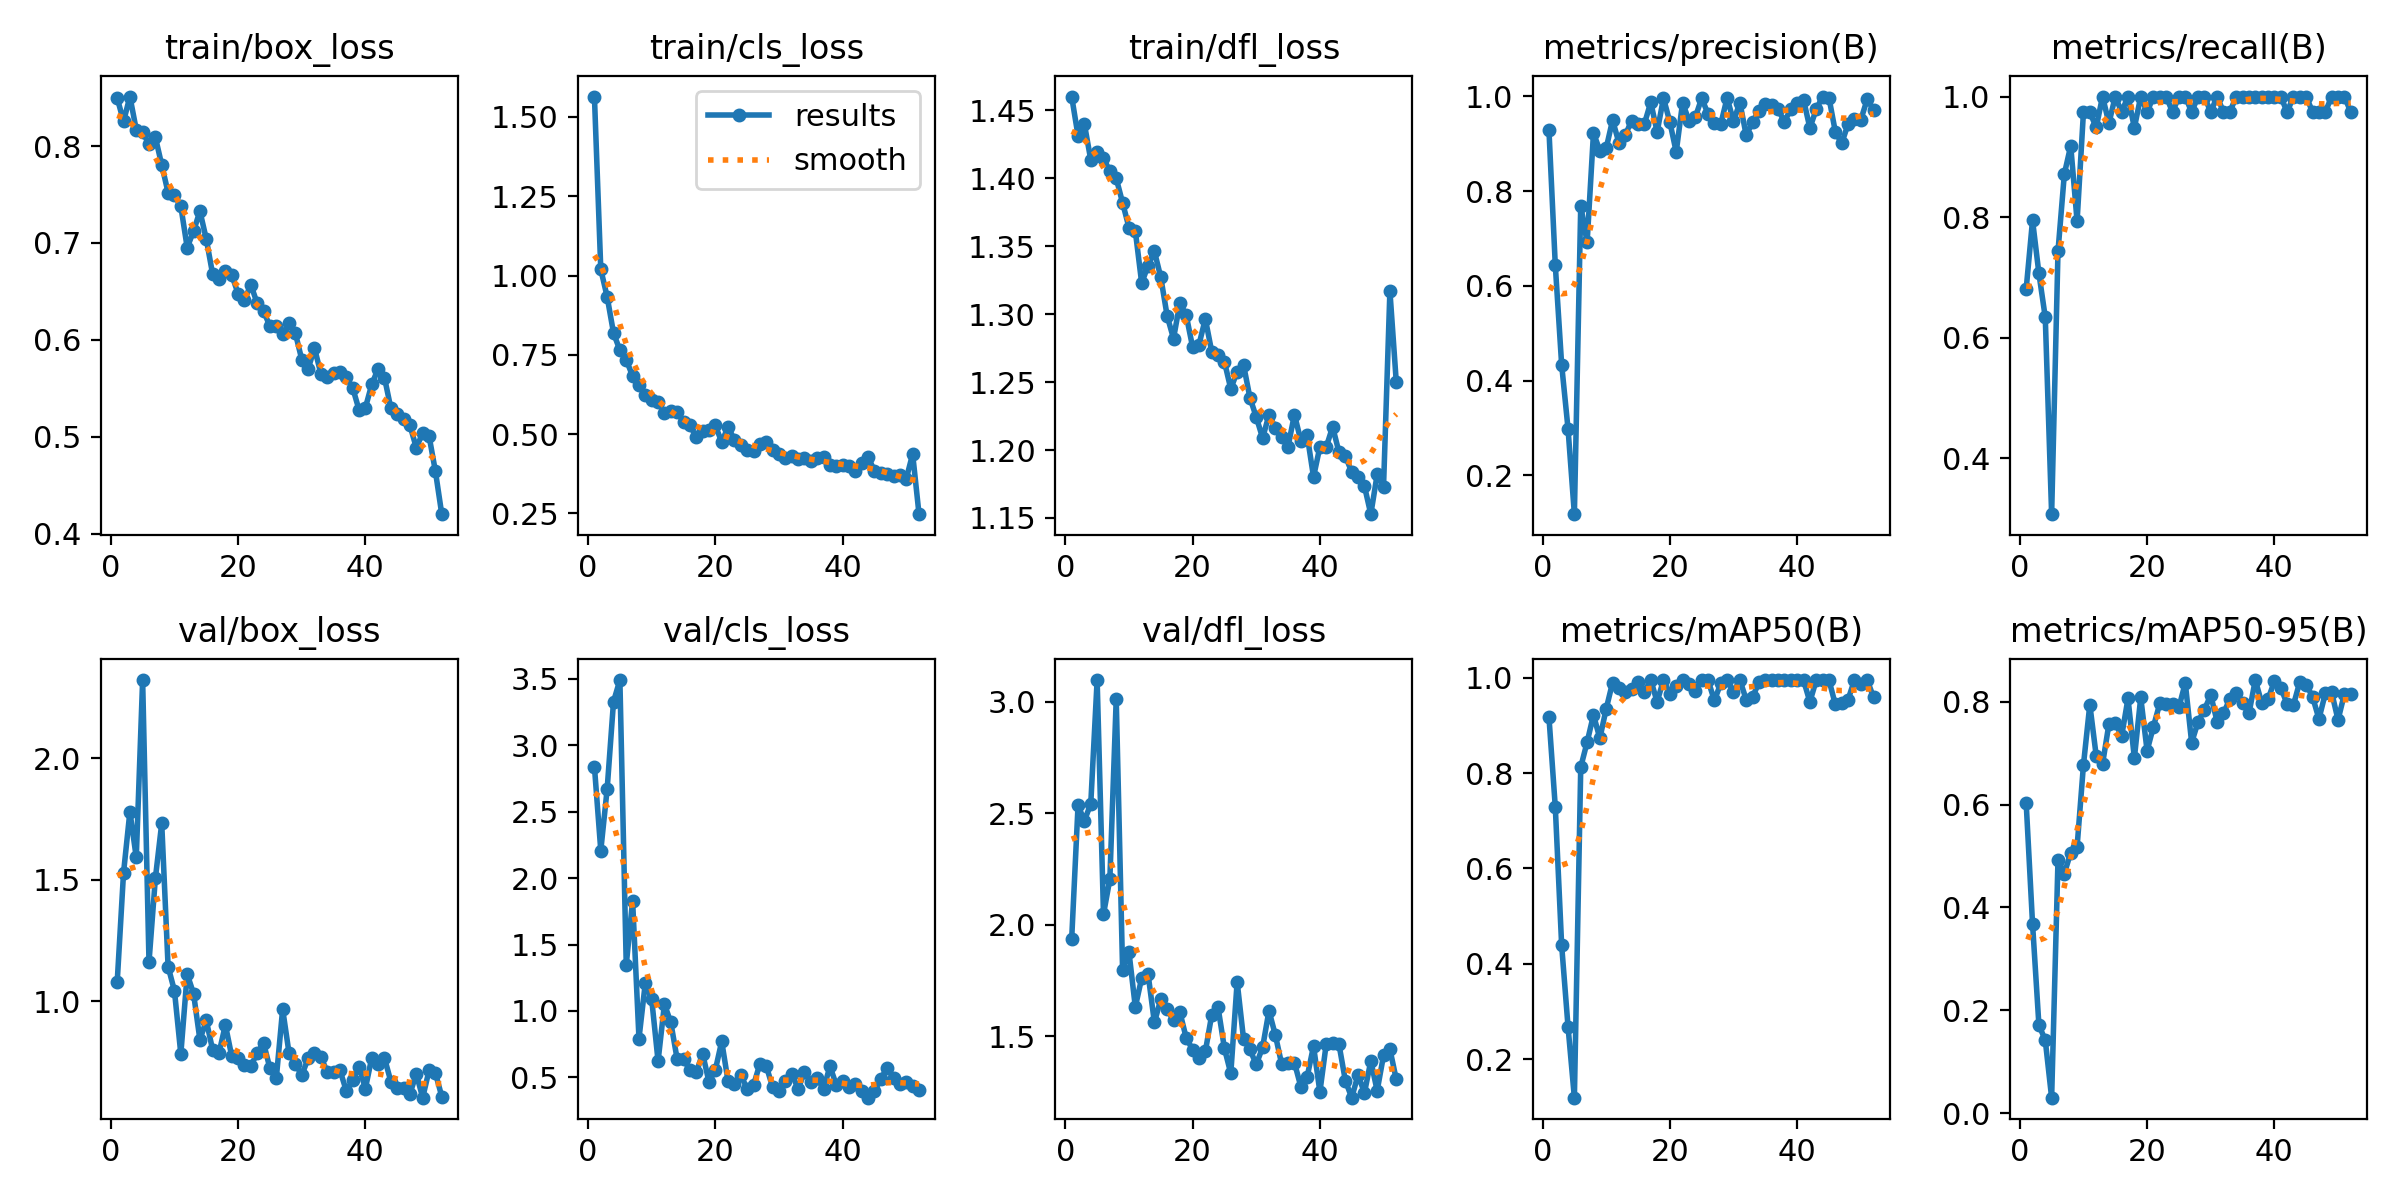

In [13]:
from IPython.display import Image as IPImage, display

run_dir = Path("/content/drive/MyDrive/receipt-ai/runs/detector/receipt_yolo")

for name in ["results.png"]:
    p = run_dir / name
    if p.exists():
        print(name)
        display(IPImage(str(p)))
    else:
        print("нет файла:", name)

confusion_matrix.png


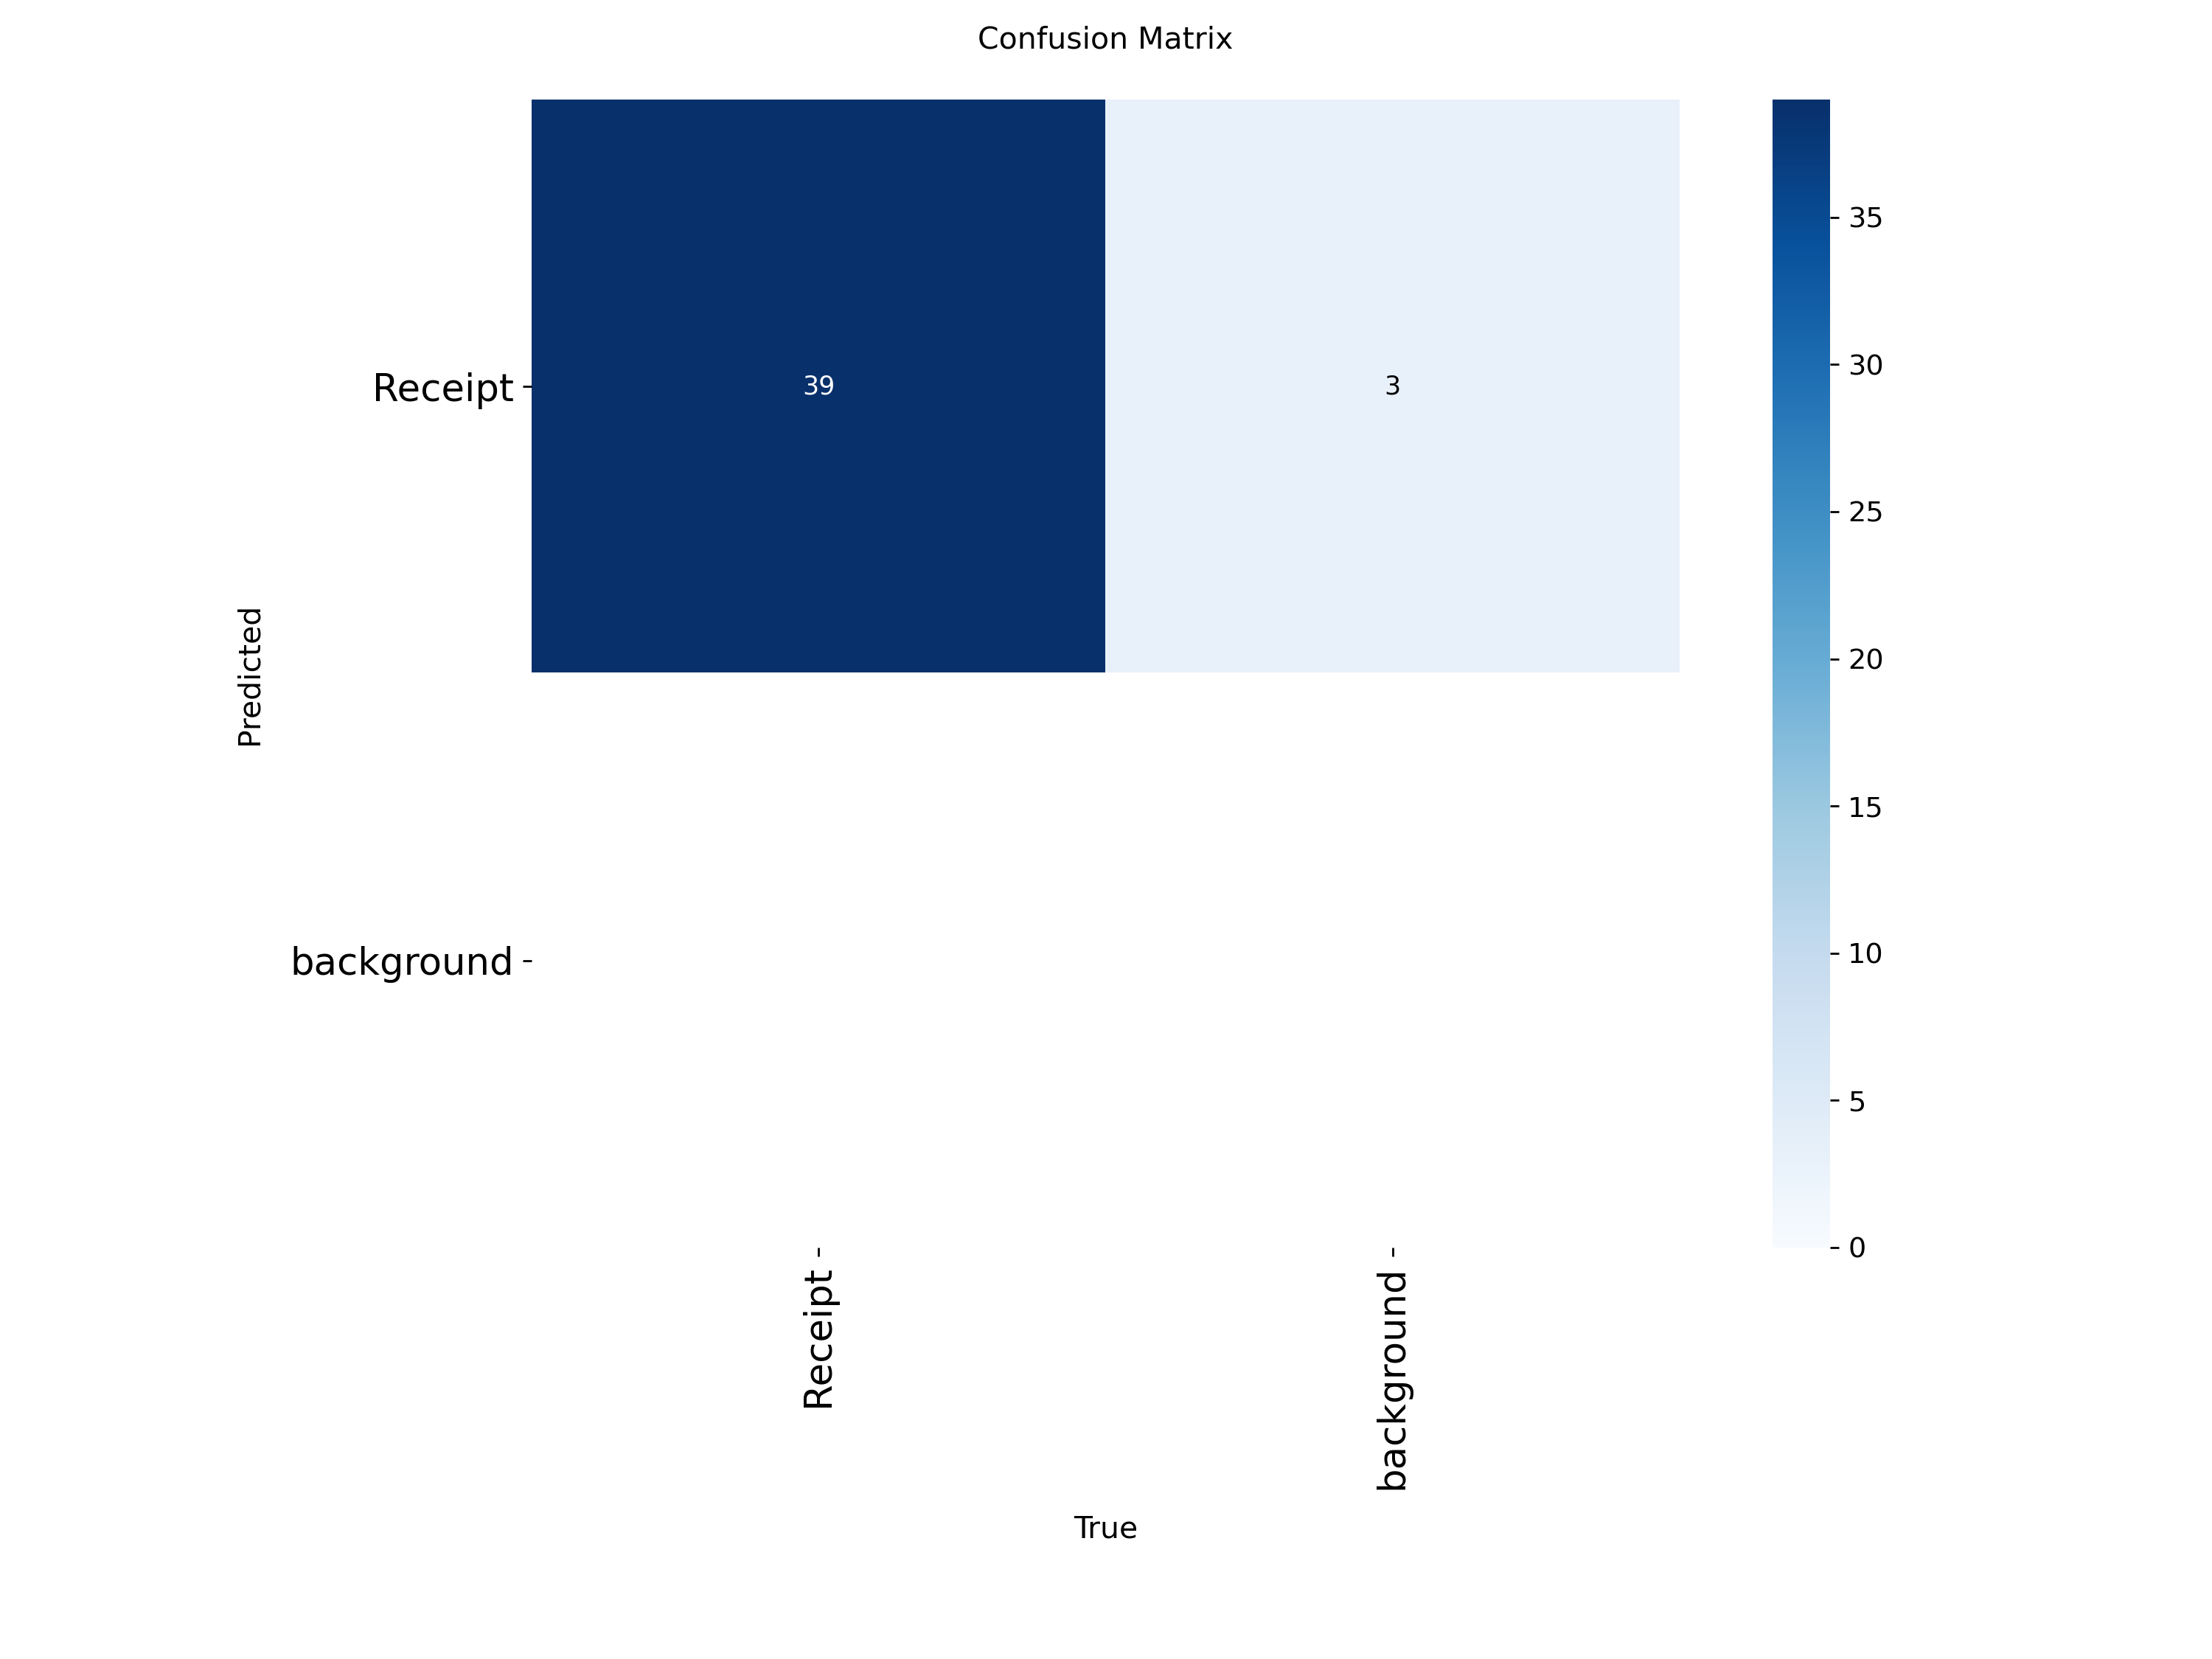

In [15]:
for name in ["confusion_matrix.png"]:
    p = run_dir / name
    if p.exists():
        print(name)
        display(IPImage(str(p)))
    else:
        print("нет файла:", name)

Графики подтверждают нормальное обучение. Все функции потерь, и на обучающей выборке, и на валидационной, последовательно убывают и выходят на плато. Ключевой признак отсутствия переобучения в том, что валидационные потери падают вместе с обучающими и не начинают расти обратно. Метрики точности, полноты и mAP быстро поднимаются в первые двадцать эпох и дальше держатся у максимума.

Матрица ошибок показывает, что все тридцать девять чеков на валидации найдены верно, пропусков нет. Три раза модель приняла за чек посторонний фон, и именно эти ложные срабатывания дают точность 0.972 вместо единицы. Для нашей задачи такая ошибка некритична: лишняя рамка на фоне менее опасна, чем пропущенный чек, и легко отсекается порогом уверенности при инференсе.

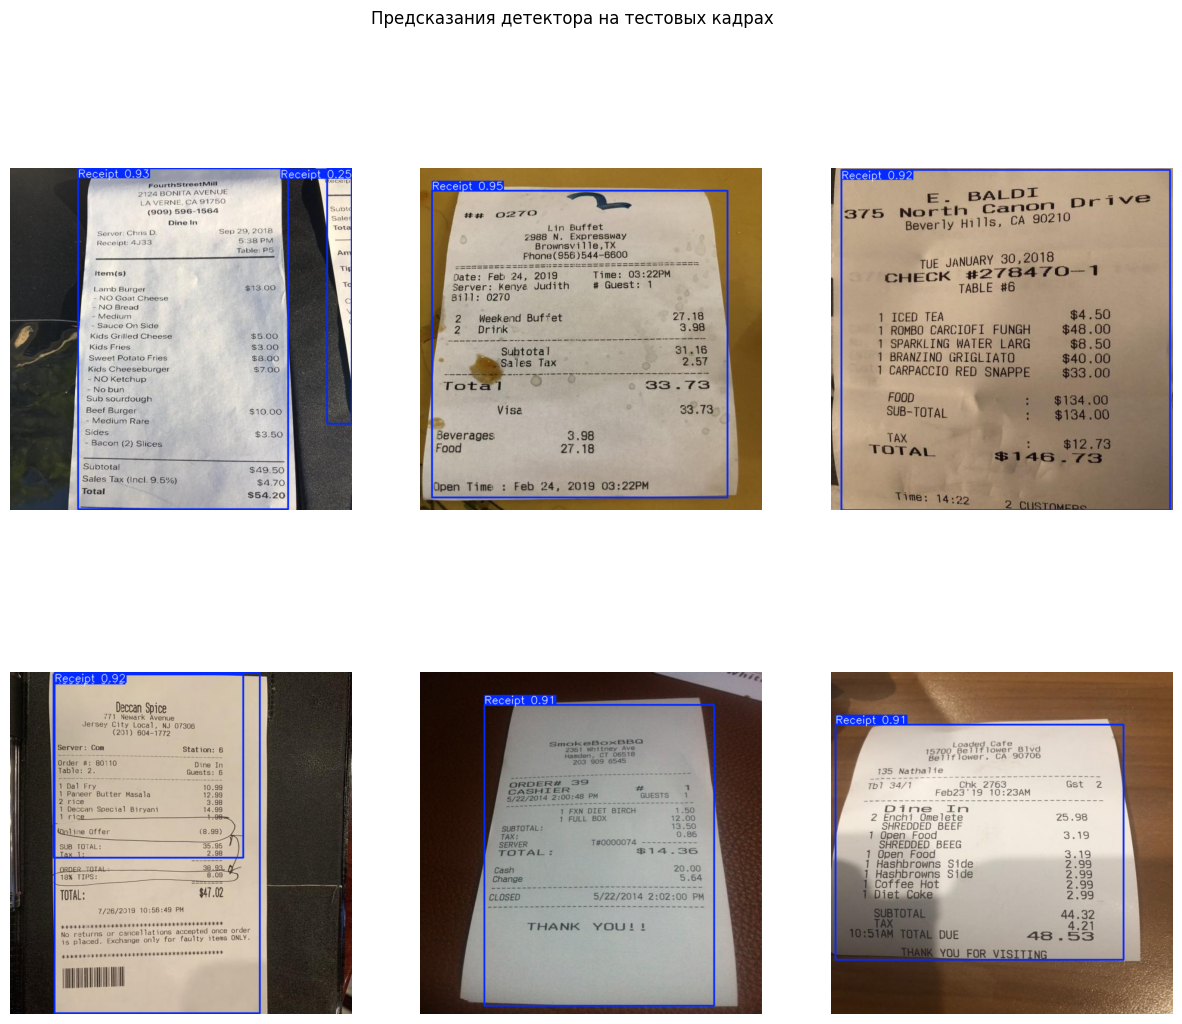

In [17]:
best_weights = run_dir / "weights" / "best.pt"
model = YOLO(str(best_weights))

test_images = sorted((data_root / "test" / "images").glob("*.jpg"))
sample_test = random.sample(test_images, min(6, len(test_images)))

fig, axes = plt.subplots(2, 3, figsize=(15, 12))
for ax, img_path in zip(axes.ravel(), sample_test):
    res = model(str(img_path), verbose=False)[0]
    annotated = res.plot()
    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    ax.imshow(annotated)
    ax.axis("off")
plt.suptitle("Предсказания детектора на тестовых кадрах")
plt.show()

Проверка на тестовых кадрах, которые модель не видела ни при обучении, ни при валидации, подтверждает качество детектора. На всех чеках рамка найдена и точно обводит чек, уверенность высокая, от 0.91 до 0.95. Чеки сняты в разных условиях, на тёмном и светлом фоне, под наклоном и прямо, и везде детекция сработала.

На одном кадре видна слабая лишняя рамка с уверенностью 0.25 на краю соседнего предмета. Это та самая редкая ошибка ложного срабатывания на фоне, что мы видели в матрице ошибок. Решается она просто: при инференсе мы отсекаем предсказания ниже порога уверенности, и тогда настоящие чеки с уверенностью выше 0.9 остаются, а слабые ложные срабатывания отбрасываются. Этот порог мы заложим в обёртку детектора.

Итак, детектор готов. Его веса сохранены на Google Drive и будут перенесены в проект для использования в составе пайплайна.

In [1]:
import importlib, src.models.detector
importlib.reload(src.models.detector)
from src.models.detector import ReceiptDetector
from src.utils.io import pil_to_cv, cv_to_pil

detector = ReceiptDetector()

for i in [0, 25]:
    img = pil_to_cv(cord_train[i]["image"])
    crop, method = detector.detect(img)
    print(f"чек {i}: метод = {method}, размер обрезки = {crop.shape}")
    fig, axes = plt.subplots(1, 2, figsize=(9, 7))
    axes[0].imshow(cord_train[i]["image"]); axes[0].set_title(f"оригинал {i}"); axes[0].axis("off")
    axes[1].imshow(cv_to_pil(crop)); axes[1].set_title(f"детектор ({method})"); axes[1].axis("off")
    plt.show()

NameError: name 'cord_train' is not defined